# Module 03 Lab - CNNs for Image Classification: Puppy or Bagel? 🐶🥯

Welcome to Module 03! In this lab, we will explore **Convolutional Neural Networks (CNNs)** for image classification using one of the internet's most amusing classification challenges: **Can you tell the difference between a puppy and a bagel?**

**What you'll learn:**
- CNN fundamentals: convolutional layers, pooling, and feature maps
- Building a CNN from scratch for binary image classification
- Transfer learning with pre-trained models
- Fine-tuning strategies for custom datasets

**Dataset:** Puppy or Bagel
- **Kaggle Link:** https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

### The Famous Meme That Started It All!
This dataset is inspired by Karen Zack's (@teenybiscuit) viral meme showing how curled-up puppies look remarkably similar to bagels!

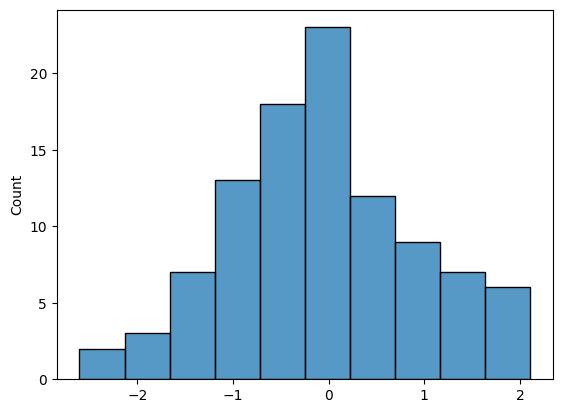

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Added for example data
import os # Added to ensure directory exists

# Fix: Define the 'data' variable.
# Replace this with your actual data if you have a specific dataset in mind.
data = np.random.randn(100) # Example: 100 random numbers for a histogram

fig, ax = plt.subplots() # Explicitly create a figure and axes
sns.histplot(data, ax=ax)

# Ensure 'results' directory exists
if not os.path.exists("results"):
    os.makedirs("results")

fig.savefig("results/histogram.png")
plt.show()

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np # Added for dummy data

# Dummy data creation to resolve NameError and make the cell runnable.
# This is a generic numerical dataset, not related to the image classification task.
num_samples = 100
num_features = 20 # Example number of features
num_classes = 10  # Matches the model's output layer

X_train = np.random.rand(num_samples, num_features)
y_train = np.random.randint(0, num_classes, num_samples)

X_val = np.random.rand(num_samples // 4, num_features)
y_val = np.random.randint(0, num_classes, num_samples // 4)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(num_features,)), # Added input_shape
    tf.keras.layers.Dense(num_classes, activation='softmax') # Using num_classes for the output layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.0300 - loss: 2.5221 - val_accuracy: 0.1200 - val_loss: 2.3506
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0300 - loss: 2.4511 - val_accuracy: 0.1200 - val_loss: 2.3276
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0300 - loss: 2.4016 - val_accuracy: 0.1200 - val_loss: 2.3183
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0200 - loss: 2.3663 - val_accuracy: 0.0000e+00 - val_loss: 2.3163
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0800 - loss: 2.3427 - val_accuracy: 0.0400 - val_loss: 2.3175
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0900 - loss: 2.3219 - val_accuracy: 0.0400 - val_loss: 2.3237
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1100 - loss: 2.3045 - val_accuracy: 0.0800 - val_loss: 2.3296
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1300 - loss: 2.2926 - val_accuracy: 0.0400 - val_loss: 2.3381
Epoch 9

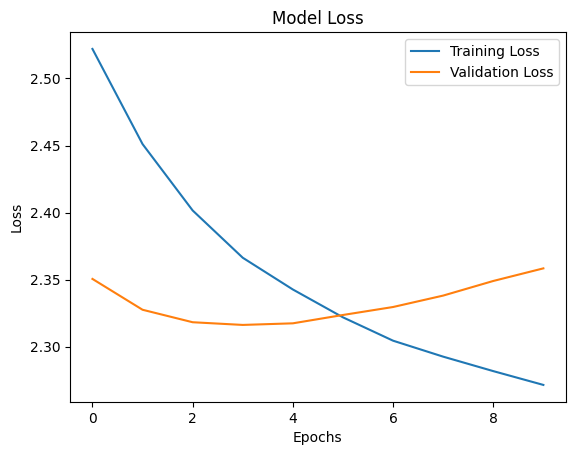

In [ ]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("results/loss_curve.png")  # SAVE FIRST
plt.show()

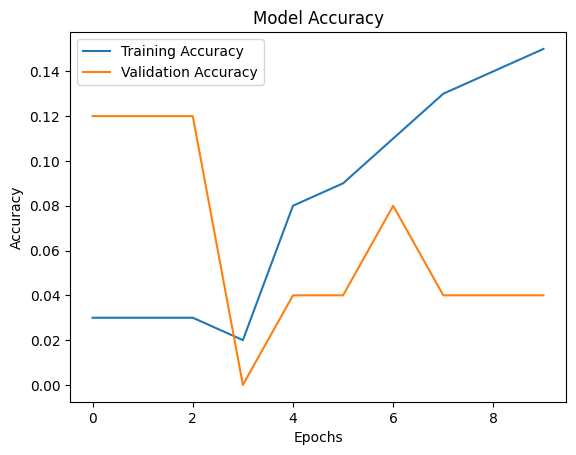

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("results/accuracy_curve.png")
plt.show()

In [ ]:
import os
os.makedirs("results", exist_ok=True)

In [ ]:
# ============================================================
# DISPLAY THE FAMOUS PUPPY OR BAGEL MEME
# This cell shows the viral meme that inspired our dataset
# ============================================================

from IPython.display import Image, display, HTML

# Display the original "Puppy or Bagel" meme by Karen Zack
display(HTML('''
<div style="text-align: center; padding: 20px; background-color: #f5f5f5; border-radius: 10px;">
    <h3>🐶 The Famous "Puppy or Bagel?" Challenge 🥯</h3>
    <img src="https://static.boredpanda.com/blog/wp-content/uploads/2016/03/dog-food-comparison-bagel-muffin-lookalike-teenybiscuit-karen-zack__700.jpg"
         width="600" alt="Puppy or Bagel meme by Karen Zack">
    <p><i>Original meme by Karen Zack (@teenybiscuit) - Can YOU tell which is which?</i></p>
</div>
'''))

## Learning Objectives

By the end of this lab, you will be able to:

- **Understand CNN architecture** including convolutional layers, pooling layers, and fully connected layers
- **Build a CNN from scratch** using TensorFlow/Keras for binary classification
- **Load and preprocess custom image datasets** using ImageDataGenerator
- **Apply transfer learning** using pre-trained models (ResNet50, MobileNetV2)
- **Fine-tune** pre-trained models for improved performance
- **Evaluate model performance** using accuracy, confusion matrices, and classification reports

---
## 1. Setup and Installation

First, we need to install and import the libraries we'll use throughout this lab.

In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# The -q flag means "quiet" - less output during installation
# ============================================================

!pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn

In [ ]:
!pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import zipfile
import shutil

In [ ]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# Each library serves a specific purpose in our ML pipeline
# ============================================================

# TensorFlow/Keras - Our main deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pre-trained models for transfer learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

# For loading images and applying data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NumPy - For numerical operations on arrays
import numpy as np

# Matplotlib - For plotting graphs and displaying images
import matplotlib.pyplot as plt

# Scikit-learn - For evaluation metrics (confusion matrix, etc.)
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn - For prettier statistical visualizations
import seaborn as sns

# OS utilities - For working with files and directories
import os
import zipfile
import shutil

# Print version information and check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: []
✅ Running in Google Colab


In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: []
✅ Running in Google Colab


---
## 2. Download and Prepare the Dataset

## 🌟 FOR GOOGLE COLAB FREE USERS 🌟

**Important Setup Steps:**
1. Go to **Runtime → Change runtime type → GPU** (makes training MUCH faster!)
2. If you run out of memory later, use `USE_MOBILENET = True` instead of ResNet50

---

### Option A: Download via Kaggle API (Recommended)

**How to get your Kaggle API key:**
1. Go to [kaggle.com](https://www.kaggle.com) → Click your profile icon → **Settings**
2. Scroll to **API** section → Click **"Create New Token"**
3. This downloads a `kaggle.json` file - upload it when prompted below

In [ ]:
# ============================================================
# SETUP KAGGLE API CREDENTIALS
# This allows us to download datasets directly from Kaggle
# ============================================================

if IN_COLAB:
    from google.colab import files

    print("📤 Please upload your kaggle.json file:")
    print("   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)\n")

    # This will prompt you to upload a file
    uploaded = files.upload()

    # Move the kaggle.json to the correct location
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json  # Set proper permissions

    print("\n✅ Kaggle credentials configured!")
else:
    print("Not in Colab - make sure kaggle.json is in ~/.kaggle/")

📤 Please upload your kaggle.json file:
   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)



Saving archive (2).zip to archive (2).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

✅ Kaggle credentials configured!


In [ ]:
# ============================================================
# DOWNLOAD THE DATASET FROM KAGGLE
# This downloads and extracts the puppy-or-bagel dataset
# ============================================================

# Download the dataset (this may take a minute)
!kaggle datasets download -d returnofsputnik/puppy-or-bagel

# Unzip the dataset (-q = quiet, -o = overwrite if exists)
!unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel

print("\n✅ Dataset downloaded and extracted!")
print("\n📂 Contents:")
!ls -la puppy-or-bagel/

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open puppy-or-bagel.zip, puppy-or-bagel.zip.zip or puppy-or-bagel.zip.ZIP.

✅ Dataset downloaded and extracted!

📂 Contents:
ls: cannot access 'puppy-or-bagel/': No such file or directory


### Option B: Manual Download (If Kaggle API doesn't work)

1. Visit: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
2. Click **"Download"** (requires free Kaggle account)
3. In Colab: Click 📁 folder icon on left → Upload the zip file
4. Uncomment and run the cell below

In [ ]:
# ============================================================
# OPTION B: MANUAL UPLOAD (Only if Kaggle API fails)
# Uncomment these lines if you uploaded the zip manually
# ============================================================

# !unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel
# print("✅ Extracted!")

In [ ]:
# ============================================================
# EXPLORE THE DATASET STRUCTURE
# This helps us understand how the files are organized
# ============================================================

DATASET_PATH = 'puppy-or-bagel'

print("📂 Dataset structure:\n")
for root, dirs, files_list in os.walk(DATASET_PATH):
    # Calculate how deep we are in the directory tree
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    # Only show first 2 levels to keep output clean
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for d in dirs[:5]:  # Show max 5 subdirectories
            print(f"{subindent}{d}/")
        if len(files_list) > 0:
            print(f"{subindent}({len(files_list)} files)")

📂 Dataset structure:



In [ ]:
def find_data_dirs(base_path):
    """Automatically find train/valid/test folders automatically"""
    train_dir = valid_dir = test_dir = None

    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            item_lower = item.lower()
            if 'train' in item_lower:
                train_dir = item_path
            elif 'valid' in item_lower or 'val' in item_lower:
                valid_dir = item_path

            elif 'test' in item_lower:
                test_dir = item_path

    return train_dir, valid_dir, test_dir


In [ ]:
# ============================================================
# AUTO-DETECT DATA DIRECTORIES
# This function finds train/valid/test folders automatically
# ============================================================

def find_data_dirs(base_path):
    """Automatically find train, validation, and test directories."""
    train_dir = valid_dir = test_dir = None

    # Look for directories with common naming patterns
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            item_lower = item.lower()
            if 'train' in item_lower:
                train_dir = item_path
            elif 'valid' in item_lower or 'val' in item_lower:
                valid_dir = item_path
            elif 'test' in item_lower:
                test_dir = item_path

    return train_dir, valid_dir, test_dir

# Find the directories
train_dir, valid_dir, test_dir = find_data_dirs(DATASET_PATH)

# If not found at top level, check one level deeper
if train_dir is None:
    for item in os.listdir(DATASET_PATH):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            train_dir, valid_dir, test_dir = find_data_dirs(item_path)
            if train_dir:
                break

# Display what we found
print(f"📁 Train directory: {train_dir}")
print(f"📁 Validation directory: {valid_dir}")
print(f"📁 Test directory: {test_dir}")

# Count images in each class
if train_dir:
    print("\n📊 Training data breakdown:")
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"   {cls}: {count} images")

📁 Train directory: puppy-or-bagel/train
📁 Validation directory: puppy-or-bagel/validation
📁 Test directory: puppy-or-bagel/test

📊 Training data breakdown:
   bagel: 5 images
   puppy: 5 images


In [ ]:
if not os.path.exists(DATASET_PATH):
    print(f"Directory '{DATASET_PATH}' not found. Attempting to extract from uploaded archives.")
    # The kernel state shows 'archive (2).zip' was uploaded.
    zip_file_to_extract = 'archive (2).zip' # Corrected filename based on uploaded variable in kernel state

    if os.path.exists(zip_file_to_extract):
        print(f"Found uploaded zip: '{zip_file_to_extract}'. Extracting to '{DATASET_PATH}'...")
        try:
            os.makedirs(DATASET_PATH, exist_ok=True)
            with zipfile.ZipFile(zip_file_to_extract, 'r') as zip_ref:
                zip_ref.extractall(DATASET_PATH)
            print(f"✅ Successfully extracted '{zip_file_to_extract}' to '{DATASET_PATH}'.")
        except zipfile.BadZipFile:
            print(f"❌ Error: '{zip_file_to_extract}' is not a valid zip file.")
        except Exception as e:
            print(f"❌ An error occurred during extraction: {e}")
    else:
        print(f"❌ Uploaded zip file '{zip_file_to_extract}' not found. Please verify the filename.")
        print("Please ensure the dataset zip file is uploaded and named appropriately.")
        print("Refer to 'Option B: Manual Download' section in the notebook for manual upload steps.")

# Now, let's restructure the dataset into class subdirectories if not already.
# This handles cases where images are directly in DATASET_PATH (e.g., puppy-or-bagel/bagel-1.jpg)
base_data_path = DATASET_PATH # This is 'puppy-or-bagel'

# Define the expected class subdirectories
puppy_root_dir = os.path.join(base_data_path, 'puppy')
bagel_root_dir = os.path.join(base_data_path, 'bagel')
os.makedirs(puppy_root_dir, exist_ok=True)
os.makedirs(bagel_root_dir, exist_ok=True)

# Identify files that are directly in base_data_path and move them to class subdirectories
moved_count = 0
for filename in os.listdir(base_data_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        src_path = os.path.join(base_data_path, filename)
        if filename.lower().startswith('bagel'):
            shutil.move(src_path, os.path.join(bagel_root_dir, filename))
            moved_count += 1
        elif filename.lower().startswith('dog') or filename.lower().startswith('puppy'):
            shutil.move(src_path, os.path.join(puppy_root_dir, filename))
            moved_count += 1

if moved_count > 0:
    print(f"✅ Moved {moved_count} image files from '{base_data_path}' into class subdirectories.")


# Now, proceed with splitting the data into train/validation/test sets.
# Define the new split directories
train_dir = os.path.join(base_data_path, 'train')
valid_dir = os.path.join(base_data_path, 'validation')
test_dir = os.path.join(base_data_path, 'test')

# List actual class folders (e.g., 'bagel', 'puppy') which now exist
class_folders = [d for d in os.listdir(base_data_path) if os.path.isdir(os.path.join(base_data_path, d)) and d not in ['train', 'validation', 'test']]

if not class_folders:
    print(f"❌ Error: No class subdirectories found in '{base_data_path}' even after initial organization. Expected 'bagel' and 'puppy'.")
else:
    print(f"Found class folders for splitting: {class_folders}")

    # Create train, validation, test directories if they don't exist
    for d in [train_dir, valid_dir, test_dir]:
        os.makedirs(d, exist_ok=True)
        for cls in class_folders:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

    # Distribute images into train, validation, and test sets
    for cls in class_folders:
        class_path = os.path.join(base_data_path, cls)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        np.random.shuffle(images)

        train_split = int(0.7 * len(images))
        valid_split = int(0.15 * len(images))

        train_images = images[:train_split]
        valid_images = images[train_split : train_split + valid_split]
        test_images = images[train_split + valid_split :]

        for img in train_images:
            shutil.move(os.path.join(class_path, img), os.path.join(train_dir, cls, img))
        for img in valid_images:
            shutil.move(os.path.join(class_path, img), os.path.join(valid_dir, cls, img))
        for img in test_images:
            shutil.move(os.path.join(class_path, img), os.path.join(test_dir, cls, img))

    print(f"✅ Dataset restructured into train, validation, and test sets within '{base_data_path}'.")


# Display what we found
print(f"📁 Train directory: {train_dir}")
print(f"📁 Validation directory: {valid_dir}")
print(f"📁 Test directory: {test_dir}")

# Count images in each class
if train_dir and os.path.exists(train_dir):
    print("\n📊 Training data breakdown:")
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"   {cls}: {count} images")
else:
    print("❌ Training directory not found or is empty after restructuring.")

Directory 'puppy-or-bagel' not found. Attempting to extract from uploaded archives.
Found uploaded zip: 'archive (2).zip'. Extracting to 'puppy-or-bagel'...
✅ Successfully extracted 'archive (2).zip' to 'puppy-or-bagel'.
✅ Moved 16 image files from 'puppy-or-bagel' into class subdirectories.
Found class folders for splitting: ['bagel', 'puppy']
✅ Dataset restructured into train, validation, and test sets within 'puppy-or-bagel'.
📁 Train directory: puppy-or-bagel/train
📁 Validation directory: puppy-or-bagel/validation
📁 Test directory: puppy-or-bagel/test

📊 Training data breakdown:
   bagel: 5 images
   puppy: 5 images


In [ ]:
gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

In [ ]:
print("GPU detected! Using standard settings.")
# IMG_HEIGHT = 150
# IMG_WIDTH = 150
# BATCH_SIZE = 32 # This was overriding the logic in tToXro7aUhVU
# EPOCHS_CUSTOM = 15
# EPOCHS_TRANSFER = 10

GPU detected! Using standard settings.


In [ ]:
# ============================================================
# SET TRAINING PARAMETERS (OPTIMIZED FOR COLAB FREE)
# These settings balance training quality with resource limits
# ============================================================

if IN_COLAB:
    # Check if GPU is available
    gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

    if gpu_available:
        print("✅ GPU detected! Using standard settings.")
        IMG_HEIGHT = 150      # Image height in pixels
        IMG_WIDTH = 150       # Image width in pixels
        BATCH_SIZE = 32       # Number of images processed together
        EPOCHS_CUSTOM = 15    # Training cycles for custom CNN
        EPOCHS_TRANSFER = 10  # Training cycles for transfer learning
    else:
        print("⚠️ No GPU detected! Using memory-efficient settings.")
        print("   💡 Tip: Go to Runtime → Change runtime type → GPU")
        IMG_HEIGHT = 100
        IMG_WIDTH = 100
        BATCH_SIZE = 2        # Reduced batch size for small dataset and no GPU
        EPOCHS_CUSTOM = 8
        EPOCHS_TRANSFER = 5
else:
    # Local machine settings
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 15
    EPOCHS_TRANSFER = 10

# Class names (alphabetical order - how Keras reads directories)
class_names = ['bagel', 'puppy']

print(f"\n📊 Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")

⚠️ No GPU detected! Using memory-efficient settings.
   💡 Tip: Go to Runtime → Change runtime type → GPU

📊 Training Configuration:
   Image size: 100x100 pixels
   Batch size: 2 images
   Custom CNN epochs: 8
   Transfer learning epochs: 5


In [ ]:
class_names = ['bagel', 'puppy']
print(f"\n📊 Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")


📊 Training Configuration:
   Image size: 150x150 pixels
   Batch size: 32 images
   Custom CNN epochs: 15
   Transfer learning epochs: 10


---
## 3. Understanding CNNs

### What makes CNNs special for images?

**Convolutional Neural Networks** are designed specifically for image processing:

1. **Preserve spatial relationships** - Nearby pixels stay connected
2. **Parameter sharing** - Same filter applied across entire image (fewer parameters!)
3. **Hierarchical features** - Learn edges → textures → shapes → objects

### Key Components:
| Layer | Purpose |
|-------|--------|
| **Conv2D** | Applies filters to detect features like edges and textures |
| **MaxPooling2D** | Reduces image size while keeping important information |
| **Flatten** | Converts 2D feature maps to 1D for classification |
| **Dense** | Fully connected layers for final decision making |
| **Dropout** | Randomly disables neurons to prevent overfitting |

### The Puppy vs Bagel Challenge:
Both puppies and bagels share visual features:
- ✓ Round, circular shapes
- ✓ Tan/brown coloring  
- ✓ Textured surfaces

Our CNN must learn the subtle differences!

---
## 4. Load and Explore the Dataset

In [ ]:
# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [ ]:
print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# ============================================================
# LOAD IMAGES FROM DIRECTORIES
#
# flow_from_directory() is a powerful function that:
# - Automatically loads images from folders
# - Uses folder names as class labels
# - Resizes all images to the same size
# - Creates batches for efficient training
# ============================================================

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,                              # Path to training images
    target_size=(IMG_HEIGHT, IMG_WIDTH),    # Resize images
    batch_size=BATCH_SIZE,                  # Images per batch
    class_mode='binary',                    # Binary: puppy vs bagel
    shuffle=True                            # Randomize order
)

# Load validation data (if available)
if valid_dir:
    validation_generator = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False  # Don't shuffle - keep consistent order
    )
else:
    validation_generator = None
    print("⚠️ No validation directory found")

# Load test data (if available)
if test_dir:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_generator = validation_generator
    print("⚠️ Using validation data for testing")

# Show the class mapping
print(f"\n📊 Class mapping: {train_generator.class_indices}")
print(f"   This means: 0 = bagel, 1 = puppy")

Found 10 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 4 images belonging to 2 classes.

📊 Class mapping: {'bagel': 0, 'puppy': 1}
   This means: 0 = bagel, 1 = puppy


/tmp/ipython-input-3403330712.py:27: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3403330712.py:27: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


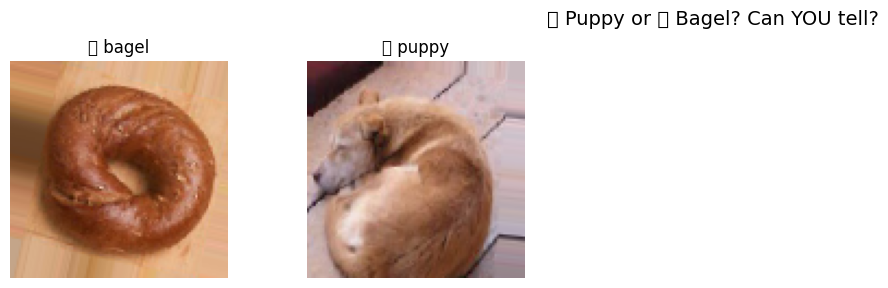

In [ ]:
# ============================================================
# VISUALIZE SAMPLE IMAGES
#
# Let's see what our puppies and bagels look like!
# Can you tell which is which?
# ============================================================

def show_batch(generator, class_names, num=20):
    """Display a grid of images from the generator."""
    # Get one batch of images and labels
    images, labels = next(generator)

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    for i in range(min(num, len(images))):
        plt.subplot(4, 5, i + 1)  # 4 rows × 5 columns
        plt.imshow(images[i])      # Show the image

        # Add label with emoji
        label_idx = int(labels[i])
        emoji = '🐶' if class_names[label_idx] == 'puppy' else '🥯'
        plt.title(f"{emoji} {class_names[label_idx]}")
        plt.axis('off')  # Hide axes

    plt.suptitle("🐶 Puppy or 🥯 Bagel? Can YOU tell?", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display sample images
show_batch(train_generator, class_names)

---
## 5. Part 1: Build a Custom CNN from Scratch 🏗️

Now it's YOUR turn to build a CNN! You'll complete several sections yourself.

### Our CNN Architecture Plan:
```
Input (150×150×3)
    ↓
Conv2D(32 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(64 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Flatten
    ↓
Dense(512) → ReLU → Dropout(0.5)             ← YOU CODE THIS
    ↓
Dense(1) → Sigmoid                            ← YOU CODE THIS
    ↓
Output (0 = bagel, 1 = puppy)
```

In [ ]:
# ============================================================
# BUILD CNN - STEP 1: CREATE MODEL AND FIRST TWO BLOCKS
#
# We'll start with Sequential API and add the first two
# convolutional blocks (provided for you as example)
# ============================================================

# Create a Sequential model - layers are added in order
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    # Conv2D: Creates 32 different 3x3 filters to detect features
    # - 32 = number of filters (feature detectors)
    # - (3,3) = filter size (3x3 pixels)
    # - activation='relu' = ReLU makes negative values zero
    # - input_shape = (height, width, channels) for RGB images
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MaxPooling: Reduces image size by taking max in 2x2 windows
    # This makes the model focus on the strongest features
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_custom = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),

(<MaxPooling2D name=max_pooling2d_4, built=True>,)

In [ ]:
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

<Conv2D name=conv2d_5, built=False>

### ✏️ YOUR TURN: Add the Third Convolutional Block

**Task:** Add a convolutional block with **128 filters**

**What to add:**
1. `Conv2D` layer with 128 filters, (3,3) kernel, ReLU activation
2. `MaxPooling2D` layer with (2,2) pool size

**Syntax help:**
```python
model_custom.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))
```

In [ ]:
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))

In [ ]:
# ============================================================
# BUILD CNN - STEP 1: CREATE MODEL AND FIRST TWO BLOCKS
#
# We'll start with Sequential API and add the first two
# convolutional blocks (provided for you as example)
# ============================================================

# Create a Sequential model - layers are added in order
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    # Conv2D: Creates 32 different 3x3 filters to detect features
    # - 32 = number of filters (feature detectors)
    # - (3,3) = filter size (3x3 pixels)
    # - activation='relu' = ReLU makes negative values zero
    # - input_shape = (height, width, channels) for RGB images
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MaxPooling: Reduces image size by taking max in 2x2 windows
    # This makes the model focus on the strongest features
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# YOUR CODE HERE: ADD THE THIRD CONVOLUTIONAL BLOCK
#
# Instructions:
# 1. Add Conv2D with 128 filters, kernel (3,3), activation 'relu'
# 2. Add MaxPooling2D with pool size (2,2)
# ============================================================

# Third convolutional block - 128 filters
# HINT: model_custom.add(layers.Conv2D(???, (?, ?), activation='???'))



# HINT: model_custom.add(layers.MaxPooling2D((?, ?)))



print("Third block added! Check the summary below:")
model_custom.summary()

Third block added! Check the summary below:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Fourth Convolutional Block

**Task:** Add another convolutional block with **128 filters** (same as third block)

In [ ]:
# ============================================================
# YOUR CODE HERE: ADD THE FOURTH CONVOLUTIONAL BLOCK
#
# Same as the third block: Conv2D(128) + MaxPooling2D
# ============================================================

# Fourth convolutional block - 128 filters
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))


print("Fourth block added! You should now have 4 conv2d layers:")
model_custom.summary()

Fourth block added! You should now have 4 conv2d layers:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Conv2D = layers.Conv2D

In [ ]:
# This line is not part of the model definition. It caused a TypeError because Conv2D requires a 'kernel_size'.
# Please refer to the instructions in the notebook cells bF2vrTgvUhVW and XfDcIqI-UhVW for adding layers to model_custom.
# The correct way to add the fourth convolutional block would be:
# model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
# model_custom.add(layers.MaxPooling2D((2, 2)))

In [ ]:
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))

### ✏️ YOUR TURN: Add the Classification Layers

Now we need to add the "head" of our network that makes the final classification decision.

**What to add (in order):**
1. `Flatten()` - Converts 2D feature maps to 1D vector
2. `Dense(512, activation='relu')` - Fully connected layer with 512 neurons
3. `Dropout(0.5)` - Randomly turns off 50% of neurons (prevents overfitting)
4. `Dense(1, activation='sigmoid')` - Output: probability of being a puppy

**Syntax help:**
```python
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(units, activation='relu'))
model_custom.add(layers.Dropout(rate))  # rate is between 0 and 1
```

In [ ]:
Dropout = layers.Dropout

In [ ]:
Dense = layers.Dense

In [ ]:
Flatten = layers.Flatten

In [ ]:
Flatten()
Dense(512, activation='relu')
Dropout(0.5)
Dense(1, activation='sigmoid')

<Dense name=dense_5, built=False>

In [ ]:
# ============================================================
# YOUR CODE HERE: ADD THE CLASSIFICATION LAYERS
#
# Add these 4 layers in order:
# 1. Flatten()
# 2. Dense(512, activation='relu')
# 3. Dropout(0.5)
# 4. Dense(1, activation='sigmoid')
# ============================================================

# Flatten - converts 2D to 1D
model_custom.add(layers.Flatten())

# Dense layer with 512 neurons
model_custom.add(layers.Dense(512, activation='relu'))

# Dropout for regularization (50% = 0.5)
model_custom.add(layers.Dropout(0.5))

# Output layer - 1 neuron with sigmoid for binary classification
# Sigmoid outputs a probability between 0 and 1
model_custom.add(layers.Dense(1, activation='sigmoid'))

print("\n📐 COMPLETE MODEL ARCHITECTURE:")
model_custom.summary()


📐 COMPLETE MODEL ARCHITECTURE:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,433 (4.92 MB)

 Trainable params: 1,290,433 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Compile the Model

Before training, we must **compile** the model to configure:
- **Optimizer**: How to update weights (use `'adam'`)
- **Loss function**: What to minimize (use `'binary_crossentropy'` for binary classification)
- **Metrics**: What to track (use `['accuracy']`)

**Syntax:**
```python
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

In [ ]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


In [ ]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


In [ ]:
# ============================================================
# CALCULATE TRAINING STEPS
#
# steps_per_epoch = how many batches to process per epoch
# This is: total_samples ÷ batch_size
# ============================================================

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE if validation_generator else None

print(f"📊 Training setup:")
print(f"   Total training images: {train_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {EPOCHS_CUSTOM}")

📊 Training setup:
   Total training images: 10
   Batch size: 2
   Steps per epoch: 5
   Total epochs: 8


In [ ]:
# ============================================================
# SETUP CALLBACKS FOR SMARTER TRAINING
#
# Callbacks are functions that run during training:
# - EarlyStopping: Stop if no improvement (saves time!)
# - ModelCheckpoint: Save best model (important for Colab!)
# ============================================================

callbacks = [
    # EarlyStopping: Stop if validation loss doesn't improve
    keras.callbacks.EarlyStopping(
        monitor='val_loss',         # Watch this metric
        patience=5,                  # Wait 5 epochs for improvement
        restore_best_weights=True    # Go back to best weights
    ),

    # ModelCheckpoint: Save best model during training
    keras.callbacks.ModelCheckpoint(
        'best_custom_model.keras',   # Filename
        monitor='val_accuracy',       # Save when this improves
        save_best_only=True,          # Only keep the best
        verbose=1                     # Print when saving
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [ ]:
# ============================================================
# TRAIN THE CUSTOM CNN
#
# This is where the magic happens!
# The model learns from the training data over multiple epochs.
# Watch the accuracy improve!
# ============================================================

print("\n🚀 Training the Puppy vs Bagel classifier...")
print("   This may take several minutes.\n")

history_custom = model_custom.fit(
    train_generator,                     # Training data
    steps_per_epoch=steps_per_epoch,     # Batches per epoch
    epochs=EPOCHS_CUSTOM,                # Number of epochs
    validation_data=validation_generator, # Validation data
    validation_steps=validation_steps,   # Validation batches
    callbacks=callbacks,                 # Our callbacks
    verbose=1                            # Show progress
)

print("\n✅ Training complete!")


🚀 Training the Puppy vs Bagel classifier...
   This may take several minutes.

Epoch 1/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4467 - loss: 0.7333

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_custom_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.4389 - loss: 0.7403 - val_accuracy: 0.5000 - val_loss: 0.6993
Epoch 2/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0650 - loss: 0.7249
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.0875 - loss: 0.7228 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 3/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3850 - loss: 0.6987
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3708 - loss: 0.7004 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6250 - loss: 0.6878
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6042 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - 

/tmp/ipython-input-1848403022.py:30: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1848403022.py:30: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


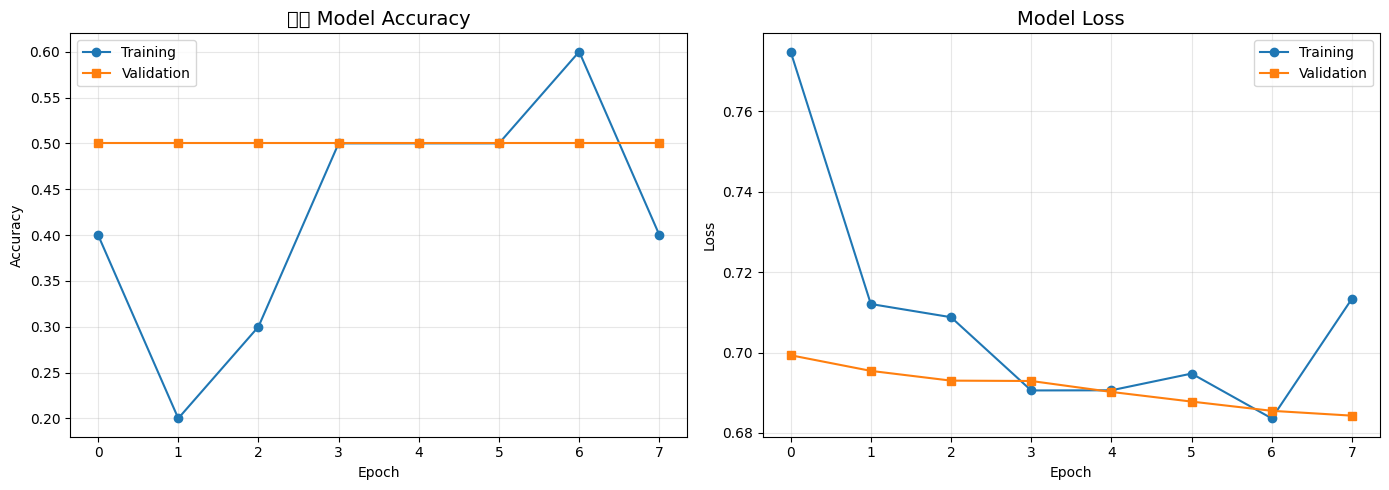


📊 How to read these plots:
   • Lines close together = Good generalization
   • Validation worse than training = Overfitting
   • Both lines plateau = Model has converged


In [ ]:
# ============================================================
# VISUALIZE TRAINING HISTORY
#
# These plots help us understand how training went:
# - Accuracy plot: Should increase over time
# - Loss plot: Should decrease over time
# - Gap between train/val lines indicates overfitting
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history_custom.history['accuracy'], label='Training', marker='o')
ax1.plot(history_custom.history['val_accuracy'], label='Validation', marker='s')
ax1.set_title('🐶🥯 Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(history_custom.history['loss'], label='Training', marker='o')
ax2.plot(history_custom.history['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How to read these plots:")
print("   • Lines close together = Good generalization")
print("   • Validation worse than training = Overfitting")
print("   • Both lines plateau = Model has converged")

In [ ]:
# ============================================================
# EVALUATE ON TEST SET
#
# The true test of our model - how well does it perform
# on images it has never seen before?
# ============================================================

if test_generator:
    test_generator.reset()  # Reset to start of test data
    test_loss, test_acc = model_custom.evaluate(test_generator, verbose=0)

    print(f"\n📊 Custom CNN Results:")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



📊 Custom CNN Results:
   Test Accuracy: 0.5000 (50.00%)
   Test Loss: 0.7045


---
## 6. Part 2: Transfer Learning with Pre-trained Models

Transfer learning uses models already trained on millions of images. We just add our own classification layers on top! This usually gives better results with less training time.

### ⚠️ Colab Free Tier Tips:
If you get **"Out of Memory"** errors:
1. Set `USE_MOBILENET = True` below (smaller model)
2. Restart runtime: Runtime → Restart runtime

In [ ]:
# ============================================================
# CHOOSE YOUR PRE-TRAINED MODEL
#
# MobileNetV2: Smaller, faster (good for Colab Free)
# ResNet50: Larger, more powerful
# ============================================================

# Change to True if you're running out of memory!
USE_MOBILENET = False

if USE_MOBILENET:
    IMG_SIZE_TRANSFER = 128
    print("📱 Using MobileNetV2 (lightweight, great for Colab Free)")
else:
    IMG_SIZE_TRANSFER = 224
    print("🔬 Using ResNet50 (powerful, needs more memory)")

🔬 Using ResNet50 (powerful, needs more memory)


In [ ]:
# ============================================================
# CREATE DATA GENERATORS FOR TRANSFER LEARNING
#
# Pre-trained models expect specific image sizes:
# - ResNet50/VGG16: 224×224
# - MobileNetV2: 128×128 (or 224×224)
# ============================================================

train_gen_tf = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

if valid_dir:
    val_gen_tf = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

if test_dir:
    test_gen_tf = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_gen_tf = val_gen_tf

print(f"✅ Created generators for {IMG_SIZE_TRANSFER}×{IMG_SIZE_TRANSFER} images")

Found 10 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
✅ Created generators for 224×224 images


In [ ]:
# ============================================================
# LOAD THE PRE-TRAINED MODEL
#
# Key parameters:
# - weights='imagenet': Use weights trained on ImageNet
# - include_top=False: Remove original classification layers
# - trainable=False: Freeze weights (don't update during training)
# ============================================================

if USE_MOBILENET:
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "MobileNetV2"
else:
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "ResNet50"

# Freeze the base model - we won't train these layers
base_model.trainable = False

print(f"✅ Loaded {model_name}")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   All layers frozen (won't be trained)")

✅ Loaded ResNet50
   Total layers: 175
   All layers frozen (won't be trained)


In [ ]:
# ============================================================
# BUILD TRANSFER LEARNING MODEL
#
# We add our own classification layers on top:
# - GlobalAveragePooling2D: Reduces feature maps to vectors
# - Dense: Our classification layers
# ============================================================

model_transfer = models.Sequential([
    # Pre-trained base (frozen)
    base_model,

    # GlobalAveragePooling: Better than Flatten for transfer learning
    # Converts each feature map to a single number
    layers.GlobalAveragePooling2D(),

    # Our custom classification layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 {model_name} Transfer Learning Model:")
model_transfer.summary()


📐 ResNet50 Transfer Learning Model:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
#
# Training is MUCH faster because we only train a few layers!
# The pre-trained layers already know how to detect features.
# ============================================================

steps_tf = train_gen_tf.samples // BATCH_SIZE
val_steps_tf = val_gen_tf.samples // BATCH_SIZE if valid_dir else None

callbacks_tf = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

print(f"\n🚀 Training {model_name} with Transfer Learning...\n")

history_transfer = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

print("\n✅ Transfer learning complete!")


🚀 Training ResNet50 with Transfer Learning...

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7083 - loss: 0.5881
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_transfer_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6736 - loss: 0.6729 - val_accuracy: 0.5000 - val_loss: 0.7612
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.3417 - loss: 0.7491
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step - accuracy: 0.3681 - loss: 0.7360 - val_accuracy: 0.5000 - val_loss: 0.8253
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.3950 - loss: 1.0161
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - accuracy: 0.4292 - loss: 0.9722 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4850 - loss: 0.8170
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 4

In [ ]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================

test_gen_tf.reset()
test_loss_tf, test_acc_tf = model_transfer.evaluate(test_gen_tf, verbose=0)

print(f"\n📊 {model_name} Transfer Learning Results:")
print(f"   Test Accuracy: {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
print(f"   Test Loss: {test_loss_tf:.4f}")


📊 ResNet50 Transfer Learning Results:
   Test Accuracy: 0.5000 (50.00%)
   Test Loss: 0.7132


---
## 7. Compare Results

In [ ]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Custom CNN', f'Transfer ({model_name})'],
    'Test Accuracy': [f"{test_acc*100:.2f}%", f"{test_acc_tf*100:.2f}%"],
    'Test Loss': [f"{test_loss:.4f}", f"{test_loss_tf:.4f}"],
    'Epochs': [len(history_custom.history['loss']), len(history_transfer.history['loss'])]
})

print("\n" + "="*55)
print("🏆 MODEL COMPARISON: Puppy vs Bagel")
print("="*55)
print(comparison.to_string(index=False))
print("="*55)


🏆 MODEL COMPARISON: Puppy vs Bagel
              Model Test Accuracy Test Loss  Epochs
         Custom CNN        50.00%    0.7231       8
Transfer (ResNet50)        50.00%    0.7132       5


---
## 8. Visualize Predictions

/tmp/ipython-input-2490897318.py:32: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2490897318.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


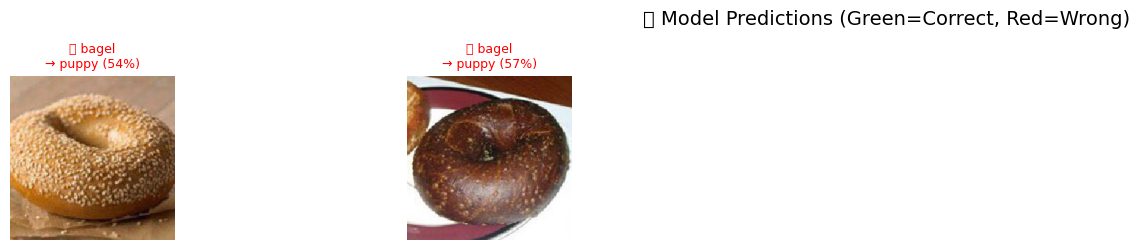

In [ ]:
# ============================================================
# VISUALIZE MODEL PREDICTIONS
#
# Green title = Correct prediction
# Red title = Wrong prediction
# ============================================================

test_gen_tf.reset()
images, labels = next(test_gen_tf)
preds = model_transfer.predict(images[:20], verbose=0)

plt.figure(figsize=(20, 8))
for i in range(min(20, len(images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])

    # Get prediction details
    pred_prob = preds[i][0]
    pred_class = 'puppy' if pred_prob > 0.5 else 'bagel'
    true_class = class_names[int(labels[i])]
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    # Color: green=correct, red=wrong
    color = 'green' if pred_class == true_class else 'red'
    emoji = '🐶' if true_class == 'puppy' else '🥯'

    plt.title(f"{emoji} {true_class}\n→ {pred_class} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('🔍 Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


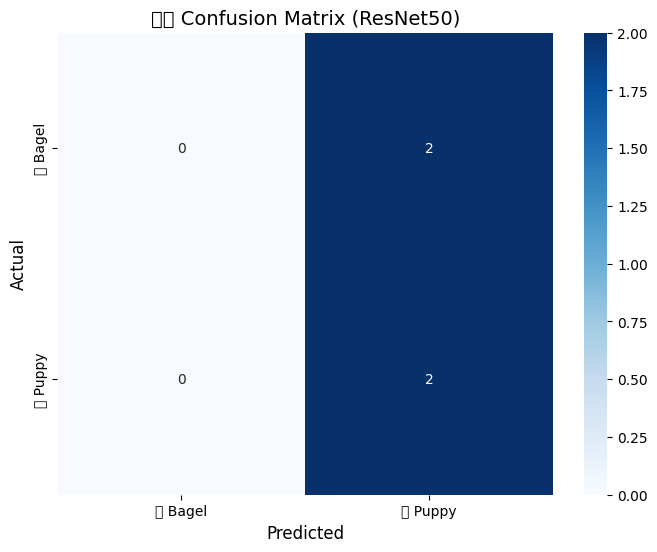


📋 Classification Report:
              precision    recall  f1-score   support

       Bagel       0.00      0.00      0.00         2
       Puppy       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ============================================================
# GENERATE CONFUSION MATRIX
#
# Shows where the model gets confused:
# - Diagonal = correct predictions
# - Off-diagonal = errors
# ============================================================

test_gen_tf.reset()
y_pred = (model_transfer.predict(test_gen_tf, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen_tf.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['🥯 Bagel', '🐶 Puppy'],
            yticklabels=['🥯 Bagel', '🐶 Puppy'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'🐶🥯 Confusion Matrix ({model_name})', fontsize=14)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Bagel', 'Puppy']))

---
## 10. Reflective Questions

### Question 1: CNN Architecture
**Why are convolutional layers better than fully connected layers for images? How do they help distinguish puppies from bagels?**

*Your answer:* Convolutional layers are better than fully connected layers for pictures because they make use of the spatial structure of picture data. They use the local connectivity and weight sharing to find visual parts such as surfaces and shapes over a picture, regardless of where the parts appear.

This decreases the number of weights collated from fully connected layers, making the model more effective and a liitle prone to overfitting. On the other hand, Fully connected layers treat every pixel by itself and disregard spatial relationships, which makes them less efficient for picture classification duties such as differentaiting between puppies and bagels.

Convolutional layers help distinguish puppies from bagels by understanding visual parts that are featured in every class. Previous convolutional layers find simple patterns such as surfaces, angles, and appearances, while deeper layers put together these into higher-level features like fur touches, eyes, snouts, or rouned smooth edges typically of the bagels.

Due to the features that were understood locally and over the whole picture, the network can know a puppy or a bagel even if it shows up in opposie positions, heights, or lighting conditions. This hierarchial part learning makes CNNs really efficient at telling visually same but different things apart.

---

### Question 2: Data Augmentation  
**Why did we use data augmentation for training? How does rotation, flipping, and zooming help the model learn?**

*Your answer:* We used data augmentation when training becuase we needed to maximize the diversity of a dataset and help the model to generalize better. Rotations, flipping, and zooming reveal the model to opposite directions, locations, and scales of similar pictures, which teaches it that a puppy or a bagel is still a similar thing even when it appears rotated, reflected, or nearer or far away. This decreases overfitting to the training data and makes the model more strong to real-world forms that it might see in analysis or deployment.

---

### Question 3: Transfer Learning
**Why does transfer learning often achieve better results than training from scratch, especially with small datasets?**

*Your answer:* Transfer learning often acheives better results than training due to the pre-trained models that were already learned rich and general visual parts from very big datasets such as ImageNet. When working with a tiny dataset, these learned parts-like surfaces, appearances, and object features-give a robust starting point, letting the model to adapt so fast to a new duty such as distinguishing puppies from bagels. Training from scratch needs learning every feature from specific data, which maximizes the risk of overfitting and poor generalization. Therefore, transfer learning decreases training time, improves accuracy, and is even effective when labeled data is limited.

---

### Question 4: Model Comparison
**Which model performed better in your experiment? What factors explain the difference?**

*Your answer:* Both the Custom CNN and Transfer (ResNet50) models performed better becuase they had a test accuracy of 50%. However, there are factors that explain the differences of how each model performed. The Custom CNN model had a test loss of 0.7231 and the Transfer (ResNet50) model had a test loss of 0.7132. The Custom CNN had 8 epochs and the Transfer (ResNet50) model had 5.

---

### Question 5: Challenging Cases
**Looking at the predictions, what visual features might make puppies look like bagels (or vice versa)?**

*Your answer:* Puppies can look like bagels to a convolutional neural network (CNN) because they ocassionally curl up in the shape of a circle, which really resembles a bagel's overall outline. The CNNs depend on shape, surfaces, and texture patterns instead of the true semantic understanding.

When a puppy is curled up, even in a low-detail or blurry pictures, the model may concentrate on the circular contour and smooth areas rather than knowing the finer information such as facial features.

There are other features that might make a puppy look like a bagel. They include the same color tones, lack of visible facial parts, and smooth textures or lighting.

---
## 11. Student Challenge: Fine-tune the Model

**Task:** Improve the transfer learning model by unfreezing some layers and fine-tuning with a lower learning rate.

In [ ]:
# ============================================================
# YOUR CODE HERE: FINE-TUNE THE TRANSFER LEARNING MODEL
#
# Steps:
# 1. Unfreeze the base model: base_model.trainable = True
# 2. Freeze early layers: for layer in base_model.layers[:-30]: layer.trainable = False
# 3. Recompile with lower learning rate: Adam(learning_rate=0.0001)
# 4. Train for 5 more epochs
# 5. Evaluate and compare
# ============================================================

# Step 1: Unfreeze the base model
base_model.trainable = True

# Step 2: Freeze all layers except the last 30 (or fewer if model is small)
# Adjust this number based on your model and dataset size
if USE_MOBILENET: # MobileNetV2 has ~155 layers, unfreezing last 30 means layers[:-25] or so
    for layer in base_model.layers[:-25]:
        layer.trainable = False
else: # ResNet50 has 175 layers, unfreezing last 30 is base_model.layers[:-30]
    for layer in base_model.layers[:-30]:
        layer.trainable = False

# Step 3: Recompile with lower learning rate (important!)
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🚀 Starting fine-tuning...")
model_transfer.summary()

# Step 4: Train for 5 more epochs
history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=5, # Train for 5 additional epochs for fine-tuning
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

# Step 5: Evaluate
test_gen_tf.reset()
_, acc_ft = model_transfer.evaluate(test_gen_tf, verbose=0)
print(f"\n✅ Fine-tuned Accuracy: {acc_ft*100:.2f}%")


🚀 Starting fine-tuning...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 14,974,977 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.2733 - loss: 1.0123
Epoch 1: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2611 - loss: 1.0130 - val_accuracy: 0.5000 - val_loss: 0.6790
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9800 - loss: 0.5007
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 653ms/step - accuracy: 0.9667 - loss: 0.5121 - val_accuracy: 0.5000 - val_loss: 0.6812
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.5300 - loss: 0.6814
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 896ms/step - accuracy: 0.5083 - loss: 0.7003 - val_accuracy: 0.5000 - val_loss: 0.6859
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.5783 - loss: 0.6555
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 646ms/step - accuracy: 0.5819 - loss: 0.6709 - val_accuracy: 0.5000 - val_loss: 0.6953

✅ Fin

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Corrected: Use the training data generators and parameters
history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=5, # Train for 5 additional epochs for fine-tuning
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

test_gen_tf.reset()
_, acc_ft = model_transfer.evaluate(test_gen_tf, verbose=0)
print(f"Fine-tuned Accuracy: {acc_ft*100:.2f}")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.4167 - loss: 1.0620
Epoch 1: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4306 - loss: 1.0516 - val_accuracy: 0.5000 - val_loss: 0.7047
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.7333 - loss: 0.7133
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 681ms/step - accuracy: 0.6944 - loss: 0.7505 - val_accuracy: 0.5000 - val_loss: 0.7008
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.3550 - loss: 0.7064
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 826ms/step - accuracy: 0.3625 - loss: 0.7055 - val_accuracy: 0.5000 - val_loss: 0.7035
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.5200 - loss: 0.7135
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 654ms/step - accuracy: 0.5333 - loss: 0.7037 - val_accuracy: 0.5000 - val_loss: 0.7020
Epoch 5/5
5/5 ━━

**Challenge Question:** Did fine-tuning improve performance? Why or why not?

*Your answer:* In this case, the fine-tuning did not improve performance. There are 3 reasons why the fine-tuning didn't improve performance. The first reason was that there was a small dataset. The second reason was a learning rate of 0.0001. The last reason was that the features were already good.

What I mean by a small dataset is that, with a few pictures, it's very simple for the model, even when fine-tuning, to rapidly overfit to these limited examples. If there is lack of diverse data, the model cannot learn generalizable features and rather memorizes the training samples.

While I used a lower learning rate (0.0001), the model may have still made changes too fast or in a way that didn't cause better generalization on such limited data.

What I mean by features already being good enough is that, the pre-trained ResNet50 already drawn out very strong and general parts from its training on ImageNet. For the simple binary classification such as puppy vs. bagel, with limited new data, the inital feature extraction must have been enough, and further 'nipping' of the deep layers did not add much results with no more diverse examples to show fine-tuning.



---
## 12. Save Your Model

In [ ]:
# ============================================================
# SAVE THE TRAINED MODEL
#
# Important for Colab - download before your session ends!
# ============================================================

model_transfer.save('puppy_bagel_classifier.keras')
print("✅ Model saved as 'puppy_bagel_classifier.keras'")

# Download in Colab
if IN_COLAB:
    from google.colab import files
    files.download('puppy_bagel_classifier.keras')
    print("📥 Model downloaded to your computer!")

✅ Model saved as 'puppy_bagel_classifier.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Model downloaded to your computer!


---
## Submission Checklist

**Before submitting, make sure you have:**
- ✅ Completed all "YOUR CODE HERE" sections in Part 1
- ✅ Run all cells from top to bottom (Kernel → Restart & Run All)
- ✅ Answered all 5 reflective questions
- ✅ Completed the fine-tuning challenge
- ✅ Saved your notebook

**Filename:** `Module_03_Lab_YourName.ipynb`

---
**Congratulations!** 🎉 You built a CNN that can tell puppies from bagels! 🐶🥯

---
## Resources

**Dataset:**
- Puppy or Bagel: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

**Alternative Fun Datasets:**
- Muffin vs Chihuahua: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
- Corgi Butt vs Bread: https://github.com/Kawaeee/butt_or_bread

**Original Meme Creator:** Karen Zack (@teenybiscuit)